=== Step 4: Data Successfully Preprocessed and Split ===

=== Step 5: Overfitting Detection (Raw Tree) ===
Train RMSE (Memorized): 0.000
Test RMSE (Unseen Data): 0.703
Notice the massive gap? This is textbook Overfitting!

=== Step 6: 5-Fold Cross-Validation ===
Mean Cross-Validation RMSE: 0.896

=== Step 7: Tuning Optimization Finished ===
Optimal Parameters Discovered: {'max_depth': 10, 'min_samples_split': 10}

=== Step 9: FINAL MODEL COMPARISON SUMMARY ===
                Model Framework  RMSE  R2 Score
     Linear Regression Baseline 0.746     0.576
      Ridge Regression Baseline 0.746     0.576
Tuned Decision Tree (Optimized) 0.645     0.682


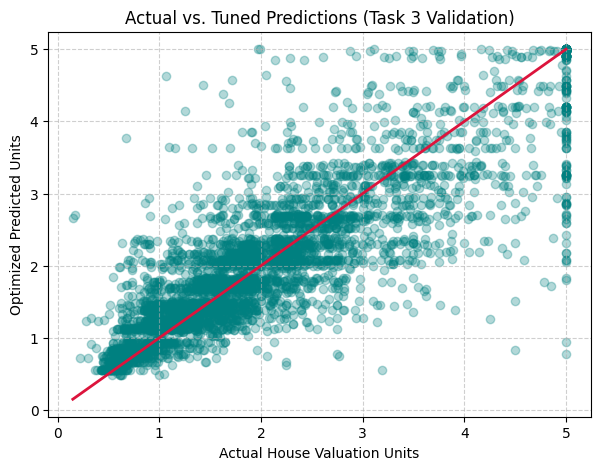

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("=== Step 4: Data Successfully Preprocessed and Split ===")

raw_tree = DecisionTreeRegressor(random_state=42)
raw_tree.fit(X_train, y_train)

train_pred = raw_tree.predict(X_train)
test_pred = raw_tree.predict(X_test)

unconstrained_train_rmse = root_mean_squared_error(y_train, train_pred)
unconstrained_test_rmse = root_mean_squared_error(y_test, test_pred)

print("\n=== Step 5: Overfitting Detection (Raw Tree) ===")
print(f"Train RMSE (Memorized): {unconstrained_train_rmse:.3f}")
print(f"Test RMSE (Unseen Data): {unconstrained_test_rmse:.3f}")
print(f"Notice the massive gap? This is textbook Overfitting!")

cv_scores = cross_val_score(
    raw_tree, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
cv_rmse = -cv_scores.mean()

print("\n=== Step 6: 5-Fold Cross-Validation ===")
print(f"Mean Cross-Validation RMSE: {cv_rmse:.3f}")

param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)
grid.fit(X_train, y_train)

print("\n=== Step 7: Tuning Optimization Finished ===")
print(f"Optimal Parameters Discovered: {grid.best_params_}")

best_tree = grid.best_estimator_
y_tree_pred = best_tree.predict(X_test)
tuned_rmse = root_mean_squared_error(y_test, y_tree_pred)
tuned_r2 = r2_score(y_test, y_tree_pred)

lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_rmse = root_mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_rmse = root_mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

results = {
    "Model Framework": ["Linear Regression Baseline", "Ridge Regression Baseline", "Tuned Decision Tree (Optimized)"],
    "RMSE": [lr_rmse, ridge_rmse, tuned_rmse],
    "R2 Score": [lr_r2, ridge_r2, tuned_r2]
}
results_df = pd.DataFrame(results)

print("\n=== Step 9: FINAL MODEL COMPARISON SUMMARY ===")
print(results_df.round(3).to_string(index=False))

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_tree_pred, alpha=0.3, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="crimson", lw=2)
plt.xlabel("Actual House Valuation Units")
plt.ylabel("Optimized Predicted Units")
plt.title("Actual vs. Tuned Predictions (Task 3 Validation)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()